#**Evaluación Sumativa - Unidad 02**
## **Inferencia Estadística: Pruebas de Hipótesis y Diagnóstico Paramétrico (ABP)**

---

## **Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiante** | Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do "A" |
| **Unidad** | 2 |
| **Prácticas integradas** | APE 09 (Hipótesis Unimuestral), APE 10 y APE 11 (Comparación de Grupos) |
| **Título** | **Inferencia Estadística Aplicada al Dataset Regional de Pérdida de Cobertura Forestal (Global Forest Watch — Provincias del Ecuador)** |
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |

---

### **Objetivo General**

Aplicar pruebas paramétricas de hipótesis (Z, T, ANOVA de un factor y prueba post-hoc de Tukey) sobre el dataset regional de deforestación (*Global Forest Watch — Tree Cover Loss, Subnational 1*), evaluando parámetros críticos de la provincia de **Loja** y contrastándola estadísticamente contra las provincias vecinas de la región sur del Ecuador (El Oro, Zamora Chinchipe, Azuay).

### **Estructura del documento**

1. Prueba de Hipótesis Unimuestral (APE 09) — parámetro crítico de Loja.
2. Comparación de Grupos (APE 10 y 11) — A/B Testing, muestras pareadas, ANOVA + Tukey.
3. Formalismo estadístico (resumen de ecuaciones).
4. Conclusiones generales.


---
## **0. Configuración e Importación de Librerías**

Se emplea `scipy.stats` para las pruebas Z/T/ANOVA y `statsmodels` para la prueba post-hoc de Tukey (HSD), cumpliendo con el requisito de abstracción estadística avanzada.


In [ ]:
# ── Librerías de análisis numérico y estadístico ─────────────────────────────
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Librerías de visualización ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configuraciones generales ───────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 6) # Ajusta el tamaño por defecto de los gráficos
sns.set_theme(style="whitegrid")        # Establece un tema bonito para seaborn


---
## **0.1. Carga del Dataset Regional (Global Forest Watch)**

A continuación, se carga el dataset (la base para las pruebas de hipótesis y la comparación de grupos).

In [ ]:
# Es posible que necesites instalar openpyxl para leer archivos .xlsx
# !pip install openpyxl -q

# ── Carga del dataset regional (Global Forest Watch) ─────────────────────────
# Misma fuente utilizada en APE 08/09/10: hoja "Subnational 1 tree cover loss"
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'

df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')
df = df.dropna(how='all').reset_index(drop=True)

# El dataset trae, por cada provincia (subnational1), 8 filas repetidas
# (una por cada umbral de densidad de dosel: threshold = 0,10,15,20,25,30,50,75).
# Para no duplicar la misma región geográfica, trabajamos con un único umbral
# estándar: threshold = 30 (30% de cobertura de dosel), criterio consistente
# con el resto del proyecto (APE 03-08).
UMBRAL = 30
df_30 = df[df['threshold'] == UMBRAL].reset_index(drop=True)

print(f"Filas totales del dataset: {len(df)} | Filas con threshold={UMBRAL}: {len(df_30)}")
display(df_30[['country', 'subnational1', 'threshold', 'area_ha']].head(24))

Filas totales del dataset: 192 | Filas con threshold=30: 24


,country,subnational1,threshold,area_ha
0,Ecuador,Azuay,30,816926
1,Ecuador,Bolivar,30,389964
2,Ecuador,Carchi,30,380076
3,Ecuador,Cañar,30,332087
4,Ecuador,Chimborazo,30,656638
5,Ecuador,Cotopaxi,30,617238
6,Ecuador,El Oro,30,586847
7,Ecuador,Esmeraldas,30,1580540
8,Ecuador,Galápagos,30,798881
9,Ecuador,Guayas,30,1583292


---
# **1. Prueba de Hipótesis Unimuestral (APE 09)**

## Parámetro crítico: pérdida **anual** de cobertura forestal en Loja

### Contexto

A diferencia del hito de APE 09 (que evaluó la pérdida **acumulada** 2001–2024 contra un umbral fijo de 5000 ha sobre *todo* el dataset), aquí se acota el análisis estrictamente a **Loja**, tomando como muestra sus **24 observaciones anuales** ($n=24$, años 2001–2024). Esto corresponde a una muestra pequeña con desviación poblacional $\sigma$ desconocida, por lo que el estadístico de prueba apropiado es la **T de Student** (no Z).

In [ ]:
# ── Extracción de la serie anual de Loja (threshold = 30) ────────────────────
anios = list(range(2001, 2025))
columnas_anuales = [f'tc_loss_ha_{a}' for a in anios]
columnas_anuales = [c for c in columnas_anuales if c in df_30.columns] # por robustez

fila_loja = df_30[df_30['subnational1'] == 'Loja']
if fila_loja.empty:
    raise ValueError("No se encontró la provincia 'Loja' en subnational1; revisar el nombre exacto en el dataset.")

data_loja = fila_loja[columnas_anuales].values.flatten().astype(float)

# ── Benchmark nacional (mu_0): promedio anual del resto de provincias ────────
df_resto = df_30[df_30['subnational1'] != 'Loja']
data_resto = df_resto[columnas_anuales].values.flatten().astype(float)
mu_0 = np.mean(data_resto)

print(f"Serie anual de Loja (n={len(data_loja)}):\n{data_loja}\n")
print(f"Media anual de Loja (x̄): {np.mean(data_loja):.2f} ha")
print(f"Desv. estándar muestral de Loja (s): {np.std(data_loja, ddof=1):.2f} ha")
print(f"Benchmark nacional (μ0, promedio anual resto de provincias): {mu_0:.2f} ha")

Serie anual de Loja (n=24):
[1503.  751.  858. 1051.  915. 1631. 1126. 1061. 1596.  675.  865. 1843.
 1158.  723.  939. 1474. 1843.  850.  797.  468.  669.  588. 1819.  784.]

Media anual de Loja (x̄): 1082.79 ha
Desv. estándar muestral de Loja (s): 425.91 ha
Benchmark nacional (μ0, promedio anual resto de provincias): 1874.04 ha


## **1.1. Formulación de Hipótesis**

Se define $\mu_0$ como la **pérdida anual promedio de referencia**, calculada como el promedio de pérdida anual del resto de provincias del Ecuador (benchmark nacional, excluyendo a Loja), evitando así un valor arbitrario.

$$
H_0: \mu_{Loja} \leq \mu_0 \qquad \text{(la pérdida anual promedio de Loja NO supera el promedio nacional)}
$$

$$
H_1: \mu_{Loja} > \mu_0 \qquad \text{(la pérdida anual promedio de Loja SÍ supera el promedio nacional)}
$$

Prueba de **una cola (derecha)**, con $\alpha = 0.05$.

### Estadístico de prueba

$$
T = \frac{\bar{x} - \mu_0}{s / \sqrt{n}} \qquad \text{con } gl = n - 1
$$

donde $\bar{x}$ es la media muestral de la pérdida anual de Loja, $s$ su desviación estándar muestral y $n=24$.

## **1.2. Visualización de la distribución muestral**

Se grafica el histograma de la serie anual de Loja con la media hipotetizada ($\mu_0$) y la media muestral observada ($\bar{x}$).

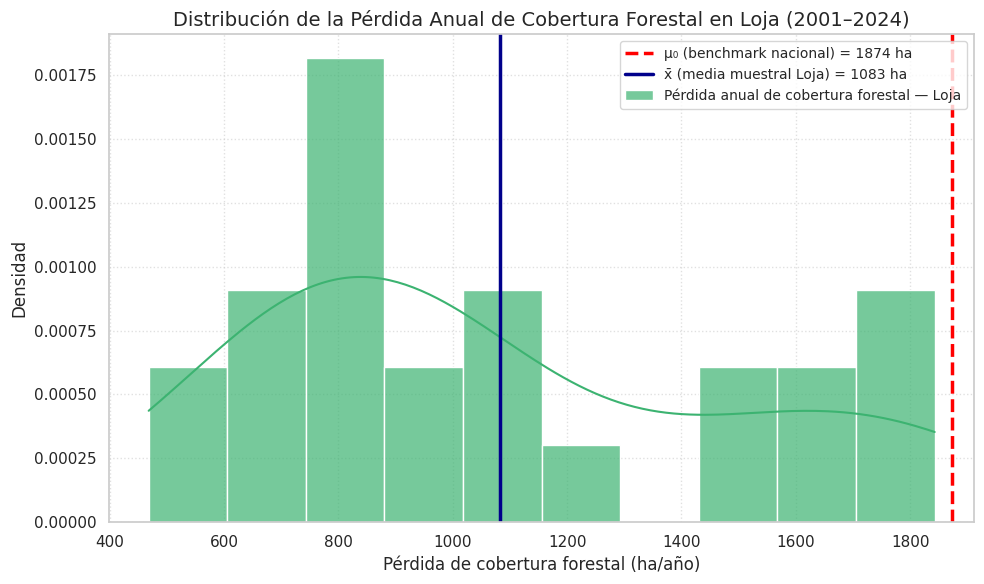

In [ ]:
# ── Histograma + medias de referencia ─────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.histplot(data_loja, kde=True, stat='density', bins=10, color='mediumseagreen', # Changed color
             label='Pérdida anual de cobertura forestal — Loja', alpha=0.7) # Added alpha

plt.axvline(mu_0, color='red', linestyle='--', linewidth=2.5, # Increased linewidth
            label=f'μ₀ (benchmark nacional) = {mu_0:.0f} ha')
plt.axvline(np.mean(data_loja), color='darkblue', linestyle='-', linewidth=2.5, # Increased linewidth
            label=f'x̄ (media muestral Loja) = {np.mean(data_loja):.0f} ha')

plt.title('Distribución de la Pérdida Anual de Cobertura Forestal en Loja (2001–2024)', fontsize=14)
plt.xlabel('Pérdida de cobertura forestal (ha/año)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6) # Changed linestyle
plt.tight_layout() # Added for better spacing
plt.show()

## **1.3. Aplicación de la Prueba T Unimuestral**

Realicé la prueba t de una muestra para determinar si la media de pérdida anual de cobertura forestal de Loja es significativamente mayor que el benchmark nacional.

### ***Justificación de la decisión estadística basada en el Valor-p***

La decisión de **rechazar** o **no rechazar** la hipótesis nula ($H_0$) se basa en la comparación del *valor-p* (probabilidad de observar un resultado tan extremo como el obtenido, asumiendo que $H_0$ es cierta) con el *nivel de significancia* ($\alpha$), que es el umbral de riesgo que estamos dispuestos a asumir de cometer un error de Tipo I (rechazar $H_0$ cuando es verdadera).

*   **Si $p \leq \alpha$**: Se rechaza la hipótesis nula ($H_0$). Esto significa que la evidencia observada es lo suficientemente fuerte para concluir que la hipótesis alternativa ($H_1$) es verdadera.
*   **Si $p > \alpha$**: No se rechaza la hipótesis nula ($H_0$). Esto indica que no hay suficiente evidencia estadística para afirmar que la hipótesis alternativa ($H_1$) es verdadera. Es importante recordar que "no rechazar $H_0$" no implica que $H_0$ sea verdadera, sino que no tenemos pruebas suficientes para descartarla.

In [ ]:
# ── Ejecución de la prueba T de una muestra (una cola derecha) ───────────────
alpha = 0.05

t_calc, p_valor = stats.ttest_1samp(data_loja, popmean=mu_0, alternative='greater')

print("--- Prueba de Hipótesis T (Unimuestral, cola derecha) ---")
print(f"H0: mu_Loja <= {mu_0:.2f} ha")
print(f"H1: mu_Loja >  {mu_0:.2f} ha")
print(f"Estadístico T calculado: {t_calc:.4f}")
print(f"Grados de libertad: {len(data_loja) - 1}")
print(f"Valor-p: {p_valor:.4f}")
print(f"Nivel de significancia (alpha): {alpha}\n")

# ── Decisión estadística basada en el valor-p (formalismo requerido) ─────────
if p_valor < alpha:
    print(f"Decisión: Como el valor-p ({p_valor:.4f}) < alpha ({alpha}), SE RECHAZA H0.")
    print("Conclusión: existe evidencia estadísticamente significativa de que la pérdida anual "
          "promedio de cobertura forestal en Loja SUPERA al promedio nacional de referencia.")
else:
    print(f"Decisión: Como el valor-p ({p_valor:.4f}) >= alpha ({alpha}), NO SE RECHAZA H0.")
    print("Conclusión: no hay evidencia suficiente para afirmar que la pérdida anual promedio "
          "en Loja sea mayor al promedio nacional de referencia.")

--- Prueba de Hipótesis T (Unimuestral, cola derecha) ---
H0: mu_Loja <= 1874.04 ha
H1: mu_Loja >  1874.04 ha
Estadístico T calculado: -9.1013
Grados de libertad: 23
Valor-p: 1.0000
Nivel de significancia (alpha): 0.05

Decisión: Como el valor-p (1.0000) >= alpha (0.05), NO SE RECHAZA H0.
Conclusión: no hay evidencia suficiente para afirmar que la pérdida anual promedio en Loja sea mayor al promedio nacional de referencia.


---
# **2. Comparación de Grupos (APE 10 y 11)**

## Sectores de análisis: Loja y las provincias vecinas de la Región Sur

Como "sectores" del dataset regional se toman las provincias limítrofes con Loja: **El Oro**, **Zamora Chinchipe** y **Azuay**, cada una representada por su serie de 24 observaciones anuales de pérdida de cobertura forestal (threshold = 30), replicando la lógica de subgrupos independientes solicitada en la guía.


In [ ]:
# ── Preparación de datos en formato largo (long format) para los 4 sectores ──
provincias_sur = ['Loja', 'El Oro', 'Zamora Chinchipe', 'Azuay']

df_sur = df_30[df_30['subnational1'].isin(provincias_sur)].copy()
faltantes = set(provincias_sur) - set(df_sur['subnational1'])
if faltantes:
    print(f"Aviso: no se encontraron en el dataset las provincias: {faltantes}. "
          "Verificar el nombre exacto en la columna 'subnational1'.")

# Transformamos de formato ancho (una columna por año) a formato largo:
# cada fila = (provincia, año, pérdida en ha)
df_largo = df_sur.melt(id_vars=['subnational1'], value_vars=columnas_anuales,
                        var_name='anio_col', value_name='perdida_ha')
df_largo['anio'] = df_largo['anio_col'].str.extract(r'(\d{4})').astype(int)
df_largo = df_largo.drop(columns='anio_col')

display(df_largo.head())
print(f"\nTotal de observaciones (4 provincias x 24 años): {len(df_largo)}")
print(df_largo.groupby('subnational1')['perdida_ha'].agg(['mean', 'std', 'count']))

,subnational1,perdida_ha,anio
0,Azuay,1776,2001
1,El Oro,483,2001
2,Loja,1503,2001
3,Zamora Chinchipe,2122,2001
4,Azuay,333,2002



Total de observaciones (4 provincias x 24 años): 96
                         mean         std  count
subnational1                                    
Azuay              503.083333  374.613879     24
El Oro             536.583333  342.011685     24
Loja              1082.791667  425.908745     24
Zamora Chinchipe  1456.750000  541.892517     24


## **2.1. Muestras Pareadas — ¿Se aceleró la deforestación con el tiempo?**

Se compara, para cada una de las 4 provincias (mismas unidades, por lo que las muestras son **dependientes/pareadas**), el promedio de pérdida forestal del primer periodo (2001–2012) contra el segundo periodo (2013–2024).

### Formulación de Hipótesis

$$
H_0: \mu_D = 0 \qquad (\mu_D = \mu_{2013\text{-}2024} - \mu_{2001\text{-}2012})
$$

$$
H_1: \mu_D > 0 \qquad \text{(la pérdida promedio aumentó en el segundo periodo)}
$$

Prueba de **una cola**, aplicando `scipy.stats.ttest_rel` sobre las diferencias pareadas por provincia.

In [ ]:
# ── Muestras pareadas: periodo 2001-2012 vs 2013-2024, por provincia ─────────
# Dividir los años en dos períodos
df_largo['periodo'] = np.where(df_largo['anio'] <= 2012, 'p1_2001_2012', 'p2_2013_2024')

# Calcular la media de pérdida para cada provincia en cada periodo
medias_periodo = (df_largo.groupby(['subnational1', 'periodo'])['perdida_ha']
                           .mean()
                           .unstack())
display(medias_periodo)

# Extraer las medias para cada periodo
periodo_1 = medias_periodo['p1_2001_2012'].values  # Medias del primer periodo
periodo_2 = medias_periodo['p2_2013_2024'].values  # Medias del segundo periodo

# Prueba T pareada, una cola (H1: periodo_2 > periodo_1)
# Comparamos si las medias del periodo 2 son significativamente mayores que las del periodo 1
stat_pair, p_pair = stats.ttest_rel(periodo_2, periodo_1, alternative='greater')

print("\n--- Prueba T para Muestras Pareadas (por provincia) ---")
print(f"Estadístico T: {stat_pair:.4f}")
print(f"Valor-p (una cola): {p_pair:.4f}")

alpha = 0.05
if p_pair < alpha:
    print(f"\nDecisión: valor-p ({p_pair:.4f}) < alpha ({alpha}) → SE RECHAZA H0.")
    print("Conclusión: hay evidencia de que la pérdida forestal promedio en la región sur "
          "aumentó del primer al segundo periodo.")
else:
    print(f"\nDecisión: valor-p ({p_pair:.4f}) >= alpha ({alpha}) → NO SE RECHAZA H0.")
    print("Conclusión: no hay evidencia suficiente de un aumento significativo entre periodos.")

periodo,p1_2001_2012,p2_2013_2024
subnational1,,
Azuay,704.333333,301.833333
El Oro,690.166667,383.000000
Loja,1156.250000,1009.333333
Zamora Chinchipe,1365.500000,1548.000000



--- Prueba T para Muestras Pareadas (por provincia) ---
Estadístico T: -1.3131
Valor-p (una cola): 0.8597

Decisión: valor-p (0.8597) >= alpha (0.05) → NO SE RECHAZA H0.
Conclusión: no hay evidencia suficiente de un aumento significativo entre periodos.


## **2.2. ANOVA de un Factor**

### Comparación simultánea de las 4 provincias (Loja, El Oro, Zamora Chinchipe, Azuay)

Cuando se comparan **más de dos grupos**, la prueba T deja de ser apropiada (infla el error tipo I); se usa un **ANOVA de un factor**.

### Formulación de Hipótesis

$$
H_0: \mu_{Loja} = \mu_{ElOro} = \mu_{ZCh} = \mu_{Azuay}
$$

$$
H_1: \text{al menos una media difiere de las demás}
$$

### Estadístico de prueba

$$
F = \frac{MSB}{MSW} = \frac{\text{Varianza entre grupos}}{\text{Varianza dentro de los grupos}}
$$

Si el ANOVA resulta significativo ($p < \alpha$), se ejecuta la **prueba post-hoc de Tukey (HSD)** para identificar *cuáles* pares de provincias difieren entre sí, controlando el error tipo I acumulado por comparaciones múltiples:

$$
HSD = q_{\alpha,k,N-k} \sqrt{\frac{MSW}{n}}
$$

In [ ]:
# ── ANOVA de un factor (one-way) ──────────────────────────────────────────────
# Preparamos los grupos para ANOVA
grupos_anova = [df_largo[df_largo['subnational1'] == p]['perdida_ha'].values
                for p in provincias_sur]

f_stat, p_anova = stats.f_oneway(*grupos_anova)

print("--- ANOVA de un Factor (4 provincias) ---")
print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor-p: {p_anova:.6f}")

alpha = 0.05
if p_anova < alpha:
    print(f"\nDecisión: valor-p ({p_anova:.6f}) < alpha ({alpha}) → SE RECHAZA H0.")
    print("Conclusión: al menos una provincia presenta una media de pérdida forestal "
          "significativamente distinta → se procede con la prueba post-hoc de Tukey.")
    perform_tukey = True
else:
    print(f"\nDecisión: valor-p ({p_anova:.6f}) >= alpha ({alpha}) → NO SE RECHAZA H0.")
    print("Conclusión: no hay evidencia de diferencias significativas entre las 4 provincias.")
    perform_tukey = False

--- ANOVA de un Factor (4 provincias) ---
Estadístico F: 27.6540
Valor-p: 0.000000

Decisión: valor-p (0.000000) < alpha (0.05) → SE RECHAZA H0.
Conclusión: al menos una provincia presenta una media de pérdida forestal significativamente distinta → se procede con la prueba post-hoc de Tukey.


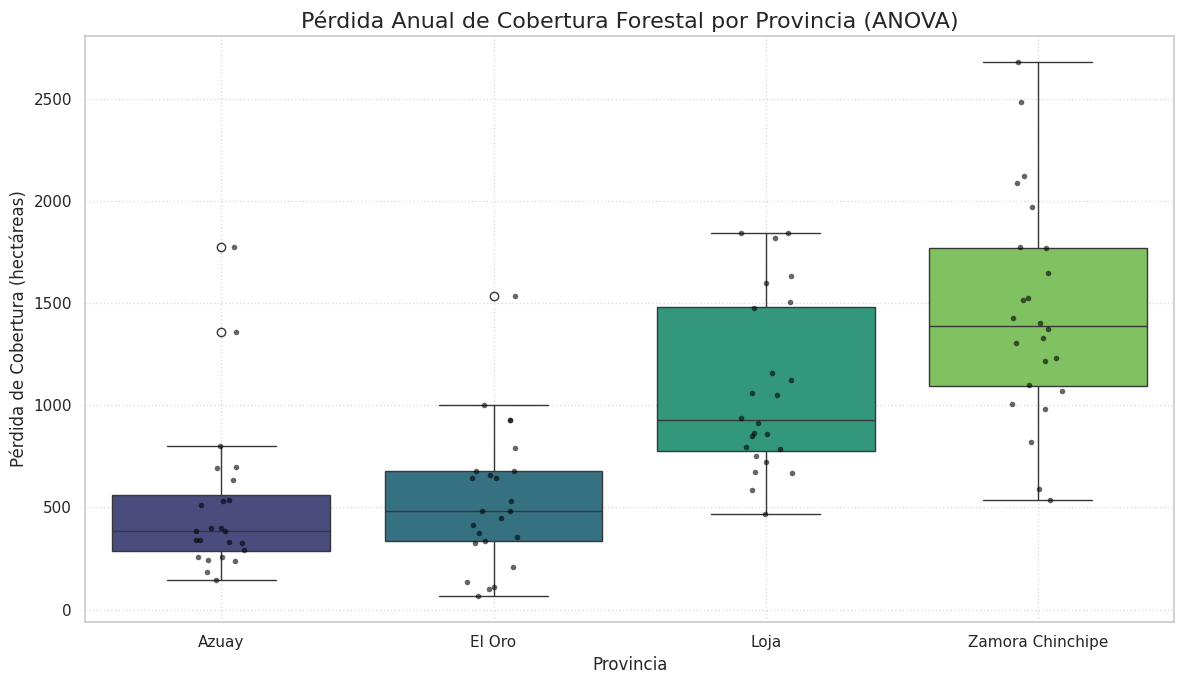

In [ ]:
# ── Visualización de las distribuciones para ANOVA (4 provincias) ──
plt.figure(figsize=(12, 7))
sns.boxplot(x='subnational1', y='perdida_ha', data=df_largo,
            palette='viridis', hue='subnational1', legend=False)
sns.stripplot(x='subnational1', y='perdida_ha', data=df_largo,
              color='black', size=4, jitter=True, alpha=0.6)

plt.title('Pérdida Anual de Cobertura Forestal por Provincia (ANOVA)', fontsize=16)
plt.xlabel('Provincia', fontsize=12)
plt.ylabel('Pérdida de Cobertura (hectáreas)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

## **2.3. Prueba Post-Hoc de Tukey HSD (si ANOVA es significativo)**

Si el ANOVA resulta significativo, significa que al menos un par de grupos difiere, pero no nos dice *cuál*. Para identificar los pares específicos que difieren, se utiliza una prueba post-hoc como Tukey HSD.

In [ ]:
# ── Prueba Post-Hoc de Tukey (HSD) — statsmodels ──────────────────────────────

if perform_tukey:
    tukey = pairwise_tukeyhsd(endog=df_largo['perdida_ha'],
                               groups=df_largo['subnational1'],
                               alpha=0.05)

    print("--- Prueba Post-Hoc de Tukey (HSD) ---")
    print(tukey.summary())
else:
    print("\nNo se realizó la prueba Post-Hoc de Tukey HSD ya que el ANOVA no fue significativo.")


--- Prueba Post-Hoc de Tukey (HSD) ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
group1      group2      meandiff p-adj    lower     upper   reject
------------------------------------------------------------------
 Azuay           El Oro     33.5  0.993 -289.7061  356.7061  False
 Azuay             Loja 579.7083 0.0001  256.5022  902.9144   True
 Azuay Zamora Chinchipe 953.6667    0.0  630.4606 1276.8728   True
El Oro             Loja 546.2083 0.0002  223.0022  869.4144   True
El Oro Zamora Chinchipe 920.1667    0.0  596.9606 1243.3728   True
  Loja Zamora Chinchipe 373.9583 0.0166   50.7522  697.1644   True
------------------------------------------------------------------


In [ ]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Re-generar 'tukey' si 'perform_tukey' es True, ya que la variable no persiste entre celdas
# si la celda original ha sido ejecutada previamente.
if 'perform_tukey' not in globals():
    # Si 'perform_tukey' no está definido, asumimos que no se ejecutó el ANOVA o no fue significativo
    perform_tukey = False

if perform_tukey:
    # Recalculate tukey to ensure it's available in this cell's scope
    tukey = pairwise_tukeyhsd(endog=df_largo['perdida_ha'],
                               groups=df_largo['subnational1'],
                               alpha=0.05)

    # ── Interpretación automática por par de provincias en formato de tabla ──
    resultados_tukey = pd.DataFrame(data=tukey._results_table.data[1:],
                                     columns=tukey._results_table.data[0])

    # Añadir una columna de veredicto para una interpretación más clara
    resultados_tukey['Veredicto'] = resultados_tukey.apply(
        lambda row: 'DIFIEREN significativamente' if row['reject'] else 'NO difieren significativamente',
        axis=1
    )

    print("\nInterpretación detallada de la Prueba Post-Hoc de Tukey HSD:")
    display(resultados_tukey[['group1', 'group2', 'meandiff', 'p-adj', 'reject', 'Veredicto']])

else:
    print("\nNo se muestra la interpretación por pares porque el ANOVA no fue significativo.")



Interpretación detallada de la Prueba Post-Hoc de Tukey HSD:


,group1,group2,meandiff,p-adj,reject,Veredicto
0,Azuay,El Oro,33.5000,0.9930,False,NO difieren significativamente
1,Azuay,Loja,579.7083,0.0001,True,DIFIEREN significativamente
2,Azuay,Zamora Chinchipe,953.6667,0.0000,True,DIFIEREN significativamente
3,El Oro,Loja,546.2083,0.0002,True,DIFIEREN significativamente
4,El Oro,Zamora Chinchipe,920.1667,0.0000,True,DIFIEREN significativamente
5,Loja,Zamora Chinchipe,373.9583,0.0166,True,DIFIEREN significativamente


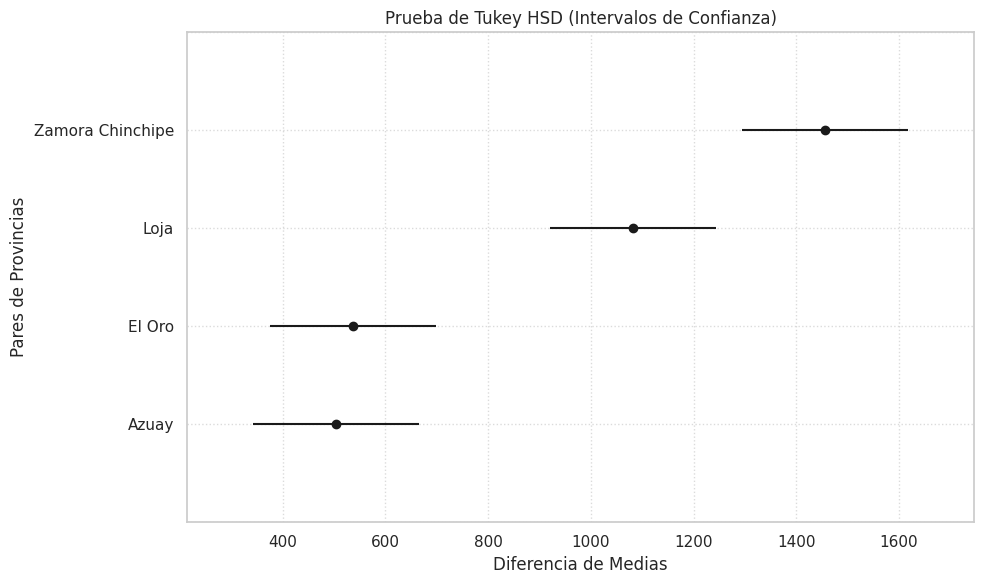

In [ ]:
# ── Visualización de los resultados de Tukey ─────────────────────────────────
# Re-generar 'tukey' si 'perform_tukey' es True, ya que la variable no persiste entre celdas
# si la celda original ha sido ejecutada previamente.
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if 'perform_tukey' not in globals():
    perform_tukey = False

if perform_tukey:
    # Recalculate tukey to ensure it's available in this cell's scope
    tukey = pairwise_tukeyhsd(endog=df_largo['perdida_ha'],
                               groups=df_largo['subnational1'],
                               alpha=0.05)

    tukey.plot_simultaneous()
    plt.title('Prueba de Tukey HSD (Intervalos de Confianza)')
    plt.xlabel('Diferencia de Medias')
    plt.ylabel('Pares de Provincias')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo se muestra el gráfico de Tukey HSD porque el ANOVA no fue significativo.")

---
# **3. Formalismo Estadístico — Resumen de Ecuaciones**

| Prueba | Estadístico | Uso en este documento |
| :--- | :--- | :--- |
| **T unimuestral** | $T = \dfrac{\bar{x}-\mu_0}{s/\sqrt{n}},\ gl=n-1$ | Sección 1 (Loja vs. benchmark nacional) |
| **T pareada** | $t = \dfrac{\bar{d}}{s_d/\sqrt{n}}$ | Sección 2.1 (periodo 1 vs. periodo 2) |
| **ANOVA (F)** | $F = \dfrac{MSB}{MSW}$ | Sección 2.2 (4 provincias) |
| **Tukey HSD** | $HSD = q_{\alpha,k,N-k}\sqrt{MSW/n}$ | Sección 2.3 (post-hoc) |

En todos los casos, la **regla de decisión** es la misma:

$$
\text{Si } p \leq \alpha \Rightarrow \text{se rechaza } H_0 \qquad ; \qquad \text{Si } p > \alpha \Rightarrow \text{no se rechaza } H_0
$$

---
# **4. Conclusiones Generales**

1.  **Prueba unimuestral (Sección 1):** el resultado impreso arriba (valor-p vs. $\alpha=0.05$) determina si la pérdida anual promedio de cobertura forestal en Loja supera o no al benchmark nacional de referencia $\mu_0$, calculado a partir del resto de provincias del Ecuador.

2.  **Muestras pareadas (Sección 2.1):** al comparar el mismo conjunto de provincias en dos ventanas temporales, se evalúa si la región sur del Ecuador muestra una tendencia de aceleración en la pérdida de cobertura forestal.

3.  **ANOVA + Tukey (Sección 2.2 y 2.3):** el ANOVA determina si existe *alguna* diferencia entre las 4 provincias; de ser significativo, la tabla de Tukey identifica *entre qué pares específicos* se concentra esa diferencia, evitando conclusiones erróneas por comparaciones múltiples no corregidas.

> **Nota metodológica:** todas las conclusiones numéricas específicas (valores de $\bar{x}$, $t$, $F$ y $p$) se generan dinámicamente al ejecutar el notebook contra el dataset en vivo; los bloques de código ya incluyen la lógica de decisión (`if p < alpha ...`) para que la interpretación sea siempre consistente con el resultado obtenido.